# Where does the J-space change across layers?

**Question:** Can we reproduce the layer-structure graphs in [section 4.1](https://transformer-circuits.pub/2026/workspace/index.html#struct-layers) for an arbitrary supported causal language model?

**Answer:** This notebook computes the **two Figure 27 CKA heatmaps** (raw and final-normalization-gain weighted) and the **Figure 28 four-panel diagnostic** from a selected model and its Jacobian lens. The saved outputs are an executed **tiny, untrained CPU demo** that validates the pipeline; they are not evidence for a workspace in a trained model. The saved demo was executed with `JLENS_RUN_MODE=demo`; normal runs default to `RUN_MODE="hf"`. Choose `MODEL_ID` and run: real-model mode now downloads a matching **prefitted HuggingFace lens** by default. Set `LENS_SOURCE = "fit"` only when you explicitly want a new fit.

The workflow reuses `model_agnostic_lens_dataset.ipynb`: `jlens.from_hf`, shared `ActivationRecorder` block outputs, `DatasetFitRun`, `load_fit_prompts`, and `fit_with_progress`. CKA computation, normalization-gain extraction, plotting, and export are implemented directly in cells below. The batched readout evaluator remains in `jlens/workspace_layers.py`. No GPT-2-specific internals are required. The model's curves need not resemble Sonnet's, and no workspace boundaries are imposed.

[Open in Colab](https://colab.research.google.com/github/ai360-project-school-j-lens/jacobian-lens-gpt2/blob/main/notebooks/model_agnostic/workspace_layers.ipynb)

Run all cells in order, locally or in a fresh Colab runtime. Setup finds a checkout or clones this fork and automatically installs its dependencies on Colab. Locally, use `uv sync --extra dev` or set `INSTALL_DEPENDENCIES=True` in setup. Set `RUN_MODE="demo"` for an offline check that downloads no model weights or lens; fresh Colab setup still downloads the repository and dependencies.

For the real experiment on Colab, select a GPU runtime, set `RUN_MODE="hf"`, and leave `LENS_SOURCE="hub"`. Qwen3.5-9B is the default (about 18 GB for bf16/fp16 weights, plus lens and activation memory); use a smaller preset for a T4 runtime. Gated models such as Gemma require HuggingFace access and authentication before model loading. If installing upgrades in an already-used kernel, restart it before continuing.

Evaluation already batches length-sorted prompts: one model forward per batch, with shared layer activations and chunked vocabulary readouts. `BATCH_SIZE` controls model batches; `POSITION_CHUNK_SIZE` controls readout memory. Reduce either if the corresponding stage runs out of memory. Colab local files disappear when its runtime is replaced: set `CACHE_ROOT` to an already-mounted Drive directory to preserve fits and results; the HuggingFace download cache is separate.

## Measurement definitions

The reference heatmap compares J-lens vector geometry across layers. Its companion panels show next-token agreement, logit kurtosis, positional persistence, and dimensionality. Curve settings below match the site's [Figure 28 data](https://transformer-circuits.pub/2026/workspace/data/layer-lines/main.json).

Our implementation makes the following estimator choices explicit:

- **Geometry, raw:** `X_l = W_U @ J_l`, centered over the full vocabulary, reproduces the original estimator.
- **Geometry, with final norm gain:** `X_l = W_U @ diag(gamma) @ J_l`, centered over the same vocabulary. Here `gamma` is the effective scale of the final normalization before the output head, not the norm inside the last transformer block. For Qwen3.5 this is `1 + norm.weight`; for Gemma4 it is `norm.weight`. The extraction cell checks the actual RMSNorm implementation instead of assuming a parameter convention. Both graphs use linear CKA between vocabulary Gram matrices, with no row normalization or vocabulary sampling. Gain weighting is not the full normalization Jacobian: it excludes input-dependent normalization and radial/centering projections, biases, and softcaps. Actual readouts include all model readout transforms.
- **Accuracy:** fraction of valid positions where the model's final top-1 token is in the layer's top-k. This is agreement with the model, not ground-truth corpus-token accuracy. Ties break by ascending token ID.
- **Kurtosis:** `mean((z - mean(z))**4) / var(z)**2 - 3` across vocabulary logits at each position. Plot position percentiles, not a single average. Constant distributions are undefined; the table reports coverage.
- **Autocorrelation:** compare top-1 token equality at original positions `t` and `t + lag` within each text. Use the exact expected repeat rate under uniform shuffling of valid positions within that text; pool counts across texts, then plot `log((observed_matches + 0.5) / (expected_matches + 0.5))`. This deterministic null and smoothing convention are our choices; the paper does not fully specify them. Missing pairs give NaN.
- **Dimensions:** the four-panel diagnostic retains the **raw** geometry. For both geometries, cached dimension tables report the minimum number of principal components explaining each requested fraction of centered vector variance, divided by residual width. Squared singular values define variance.

Block outputs are indexed from zero: the first block is displayed at 0 and the final block at 100. This is a normalized depth convention, not an embedding-layer measurement. Select at most 25 roughly evenly spaced blocks. Padding and special input tokens are excluded; all other positions, including the last real token, are eligible. Lags retain gaps from excluded tokens.

The default held-out data are the repository's task prompts. This differs from the paper's corpus. For a representative study, use your own independent evaluation corpus through `EVAL_JSONL`, increase the fit sample, and compare results across seeds. The ambiguous-input intervention later in section 4.1 is a separate experiment and is not implemented here.

In [1]:
import hashlib
import importlib.metadata
import json
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
INSTALL_DEPENDENCIES = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
REPO_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "jlens" / "evaluation.py").is_file()), None,
)
if REPO_DIR is None:
    REPO_DIR = Path.cwd() / "jacobian-lens-gpt2"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
REPO_DIR = REPO_DIR.resolve()
required_files = ("jlens/evaluation.py", "jlens/workspace_layers.py")
if any(not (REPO_DIR / name).is_file() for name in required_files):
    raise RuntimeError(
        f"Checkout at {REPO_DIR} lacks workspace evaluation code. "
        f"Update it with: git -C {REPO_DIR} pull --ff-only"
    )
if INSTALL_DEPENDENCIES:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)],
        check=True,
    )
# Colab may preload Matplotlib. Pip can replace files while old classes remain
# in memory; a newly imported SVG backend then sees an incompatible Text API.
loaded_matplotlib = sys.modules.get("matplotlib")
if loaded_matplotlib is not None:
    installed_version = importlib.metadata.version("matplotlib")
    loaded_version = getattr(loaded_matplotlib, "__version__", None)
    if loaded_version != installed_version:
        raise RuntimeError(
            f"Matplotlib changed from loaded {loaded_version} to installed {installed_version}. "
            "Restart the Colab session/runtime now, then run all cells again. "
            "Cached measurements on disk are retained; no factory reset is needed."
        )
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repository:", REPO_DIR)
print("Dependencies installed." if INSTALL_DEPENDENCIES else "Using the current Python environment.")

Repository: /home/kitlix/projects/jacobian-lens-gpt2
Using the current Python environment.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from huggingface_hub import hf_hub_download
from IPython.display import display

import jlens
from jlens.evaluation import (
    DATASETS,
    FIT_MIX,
    fit_with_progress,
    load_eval,
    load_fit_prompts,
)
from jlens.notebook_setup import DatasetFitRun, runtime_metadata, save_json
from jlens.sharded_fitting import benchmark_dim_batches
from jlens.workspace_layers import workspace_readouts

%matplotlib inline

## Configuration

The saved outputs are from an explicit offline `JLENS_RUN_MODE=demo` run. The default `RUN_MODE="hf"` loads the selected model **and its prefitted lens**, following the pretrained-summary notebook. The default real model is `Qwen/Qwen3.5-9B`, paired with `bcywinski/jacobian-lens-qwen3.5-9b/lens_n1000.pt`, as in the existing Qwen3.5-9B summary notebook. Smaller Qwen3 presets and Gemma-4-31B are also available. Change `MODEL_ID` and select the corresponding entry in `HUB_LENS`, or supply another Hub repo/file pair for your model. The Gemma preset is the same artifact used by `pretrained_generated_answer_summary.ipynb`.

`LENS_SOURCE="hub"` downloads directly with `huggingface_hub.hf_hub_download` and reuses its cache. No published LFS metadata or separate metadata verification is required. `LENS_SOURCE="local"` loads `EXISTING_LENS_PATH`. Neither mode downloads fitting corpora, calibrates, or fits. Errors stop the load. To fit deliberately, select `LENS_SOURCE="fit"`.

The notebook checks residual width, layer coverage, matrix shape, and finite values. Use a **final** lens, not a fit checkpoint. A custom adapter needs `LensModel` plus an explicit linear unembedding weight for geometry.

Model selection examples (edit configuration below before running):

| Model | Lens source | Final normalization gain |
| --- | --- | --- |
| `Qwen/Qwen3.5-9B` (default) | Matching Hub preset | `1 + weight` |
| `google/gemma-4-31B` | Matching Hub preset | `weight` |
| `google/gemma-2-2b` | Matching Hub preset; smaller Gemma option | `1 + weight` |
| `openai-community/gpt2-xl` | Set `LENS_SOURCE="local"` and `EXISTING_LENS_PATH` to your GPT-2-XL lens, or explicitly choose `"fit"` | LayerNorm `weight` |

No verified GPT-2-XL Hub preset is bundled. A GPT-2-small lens is not compatible. To use a published GPT-2-XL artifact of your own, set its `HUB_LENS` repo/file. All these models use the same inline CKA and batched readout code; the adapter locates GPT-2-XL's `transformer.ln_f` and Gemma's final text-decoder norm. Gemma models require access to the corresponding gated model.


In [3]:
RUN_MODE = os.environ.get("JLENS_RUN_MODE", "hf")  # "demo" is an explicit offline check.
MODEL_ID = "Qwen/Qwen3.5-9B"
# Alternatives: "google/gemma-4-31B", "google/gemma-2-2b", "openai-community/gpt2-xl"
# GPT-2-XL: select LENS_SOURCE="local" plus EXISTING_LENS_PATH, or explicitly "fit".
MODEL_REVISION = None  # Pin a HuggingFace commit for repeatable model weights.
LENS_SOURCE = "hub"  # "hub", "local", or explicitly "fit"; demo always uses a tiny fit.
PREFITTED_LENSES = {
    "Qwen/Qwen3.5-9B": ("bcywinski/jacobian-lens-qwen3.5-9b", "lens_n1000.pt"),
    "Qwen/Qwen3-1.7B": ("neuronpedia/jacobian-lens", "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt"),
    "Qwen/Qwen3-4B": ("neuronpedia/jacobian-lens", "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt"),
    "google/gemma-2-2b": ("neuronpedia/jacobian-lens", "gemma-2-2b/jlens/Salesforce-wikitext/gemma-2-2b_jacobian_lens.pt"),
    "google/gemma-4-31B": ("neuronpedia/jacobian-lens", "gemma-4-31b/jlens/Salesforce-wikitext/gemma-4-31B_jacobian_lens.pt"),
}
lens_repo, lens_filename = PREFITTED_LENSES.get(MODEL_ID, (None, None))
HUB_LENS = dict(repo_id=lens_repo, filename=lens_filename, revision="main")
# For another model, supply its matching repo_id and filename in HUB_LENS.
EXISTING_LENS_PATH = None  # LENS_SOURCE="local": Path("/path/to/matching/final/lens.pt")
EVAL_JSONL = None  # Optional JSONL file, one {"text": "...", "source": "..."} per line.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# T4 and other older Colab GPUs use fp16; bf16 requires hardware support.
DTYPE = (
    torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported(including_emulation=False)
    else torch.float16 if DEVICE == "cuda" else torch.float32
)
MAX_SEQ_LEN = 128
N_PLOT_LAYERS = 25
BATCH_SIZE = 8  # Prompts per shared model forward; lower for limited GPU memory.
POSITION_CHUNK_SIZE = 32  # Reduce for large vocabularies.
NORM_GAIN_OVERRIDE = None  # Custom norm: supply its effective [d_model] scale.
GEOMETRY_DEVICE = "cpu"  # CPU/CUDA with float64 support; independent of model device.
VOCAB_CHUNK_SIZE = 4096
EVAL_ITEMS_PER_DATASET = 24
FIT_FRACTION = 0.25
FIT_SEED = 0
DIM_BATCH = None  # Measure safe candidates in HF mode; demo uses width 8.
RUN_LABEL = "workspace-layers-v1"
CACHE_ROOT = REPO_DIR / "runs" / "workspace_layers"  # gitignored; temporary on Colab
# Optional, after mounting Drive yourself:
# CACHE_ROOT = Path("/content/drive/MyDrive/jacobian-lens-runs/workspace_layers")

KS = (1, 2, 4, 8, 16, 32, 64, 128)
PERCENTILES = (1, 10, 25, 50, 75, 90, 99)
LAGS = (1, 2, 4, 8, 16, 32)
VARIANCE_THRESHOLDS = (0.9, 0.95, 0.98, 0.99, 0.995)
assert RUN_MODE in {"demo", "hf"}
assert LENS_SOURCE in {"hub", "local", "fit"}
if RUN_MODE == "hf" and LENS_SOURCE == "hub" and not HUB_LENS.get("filename"):
    raise ValueError(
        "No verified Hub preset for this MODEL_ID (including GPT-2-XL). "
        "Supply its matching HUB_LENS repo/file, or set LENS_SOURCE='local' "
        "and EXISTING_LENS_PATH, or explicitly choose LENS_SOURCE='fit'."
    )
if RUN_MODE == "hf" and LENS_SOURCE == "local" and EXISTING_LENS_PATH is None:
    raise ValueError("Set EXISTING_LENS_PATH for LENS_SOURCE='local'.")

In [4]:
if RUN_MODE == "demo":
    from tests.tiny import TinyDecoder

    model = TinyDecoder(n_layers=6, seed=FIT_SEED).eval()
    unembedding_weight = model.lm_head.weight
    final_norm = model.norm
    runtime = dict(model_id="offline/TinyDecoder", dtype="float32", device="cpu",
                   d_model=model.d_model, n_layers=model.n_layers, seed=FIT_SEED,
                   torch_version=str(torch.__version__))
    demo_fit_texts = [
        "A small decoder is useful for checking linear algebra and hooks.",
        "Independent fitting examples never include the evaluation prompts.",
        "The cache records the exact ordered fitting corpus and settings.",
        "Numerical checks compare batched results against direct calculations.",
    ]

    def fit_prompt_loader(mix, seed):
        return pd.DataFrame({"source": "synthetic-demo", "text": demo_fit_texts})
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    hf_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, revision=MODEL_REVISION, dtype=DTYPE,
    ).to(DEVICE).eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
    model = jlens.from_hf(hf_model, tokenizer, compile=False)
    head = hf_model.get_output_embeddings()
    if type(head) is not torch.nn.Linear:
        raise TypeError("Geometry requires a plain linear head or an explicit W_U.")
    unembedding_weight = head.weight
    final_norm = hf_model.get_submodule(f"{model.layout.path}.{model.layout.norm}")
    runtime = runtime_metadata(model, hf_model, MODEL_ID, DTYPE, DEVICE)
    fit_prompt_loader = load_fit_prompts

assert model.n_layers >= 2
layers = np.unique(np.linspace(0, model.n_layers - 1,
                              min(N_PLOT_LAYERS, model.n_layers)).round().astype(int)).tolist()
label = "OFFLINE DEMO — untrained TinyDecoder" if RUN_MODE == "demo" else runtime["model_id"]
print(label)
display(pd.DataFrame([runtime]))
print("Measured block indices:", layers)
print(f"Stored geometry matrices: ~{len(layers) * model.d_model**2 * 4 / 2**30:.2f} GiB, "
      "plus float64 workspaces, lens matrices, activations and model weights.")

OFFLINE DEMO — untrained TinyDecoder


,model_id,dtype,device,d_model,n_layers,seed,torch_version
0,offline/TinyDecoder,float32,cpu,8,6,0,2.12.0+cu130


Measured block indices: [0, 1, 2, 3, 4, 5]
Stored geometry matrices: ~0.00 GiB, plus float64 workspaces, lens matrices, activations and model weights.


## Load the prefitted lens (or explicitly fit)

For real models, `LENS_SOURCE="hub"` loads the selected HuggingFace artifact and records the selected repo, filename, revision and local file hash with the measurements. `"local"` reads a supplied final file. These branches never invoke `DatasetFitRun` or fitting. Final-layer readout always uses identity transport.

Only `LENS_SOURCE="fit"` (or the offline demo) uses the managed fitting configuration from the generic dataset notebook. It saves the ordered corpus and settings, excludes the first 16 positions and final position during fitting, and reuses completed fits. These settings do **not** describe a downloaded lens. Evaluation has separate position selection.

Geometry uses exact full-vocabulary covariance, avoiding a vocabulary-squared matrix. It still costs cubic work in residual width for eigendecompositions and retains approximately `4 * number_of_layers * d_model**2` bytes of Gram features, plus workspaces. Large models may need substantial CPU RAM and time.

In [5]:
# Invalidate dependent state before loading, including on download/validation failure.
fitted_lens = lens_path = lens_provenance = fit_run = None
readouts = geometry = gain_geometry = measurement_config = None
source = "fit" if RUN_MODE == "demo" else LENS_SOURCE
if source == "hub":
    lens_path = Path(hf_hub_download(**HUB_LENS))
    lens_provenance = {"source": "hub", **HUB_LENS, "path": str(lens_path)}
    candidate_lens = jlens.JacobianLens.load(str(lens_path))
    display(lens_provenance)
    print("Loaded prefitted HuggingFace lens; no fitting or calibration.")
elif source == "local":
    lens_path = Path(EXISTING_LENS_PATH).expanduser().resolve()
    candidate_lens = jlens.JacobianLens.load(str(lens_path))
    lens_provenance = {"source": "local", "path": str(lens_path),
                       "fitting_provenance": "external; unverified"}
    print("Loaded local prefitted lens; no fitting or calibration.")
elif source == "fit":
    fit_config = {
        **runtime,
        "max_seq_len": MAX_SEQ_LEN, "skip_first": 16,
        "fit_mix": ({"synthetic-demo": 4} if RUN_MODE == "demo" else
                    {source: max(1, round(n * FIT_FRACTION)) for source, n in FIT_MIX.items()}),
        "seed": FIT_SEED, "run_label": RUN_LABEL,
        "checkpoint_every": 5,
        "dim_batch_requested": 8 if RUN_MODE == "demo" else DIM_BATCH,
        "candidates": [4, 8, 16, 32],
        "headroom_fraction": 0.15, "headroom_GiB": 2.0,
    }
    fit_run = DatasetFitRun(CACHE_ROOT / "fits", fit_config)
    fit_run.print_paths()
    candidate_lens = fit_run.load_or_fit(
        model, fit_config, load_prompts=fit_prompt_loader, fit=fit_with_progress,
        benchmark=benchmark_dim_batches, display=display,
    )
    lens_path = fit_run.lens_path
    lens_provenance = {"source": "managed-fit", "manifest": str(fit_run.manifest_path)}
else:
    raise ValueError("LENS_SOURCE must be 'hub', 'local', or 'fit'.")

required = set(range(model.n_layers - 1))
if candidate_lens.d_model != model.d_model:
    raise ValueError("Lens/model residual widths differ; select the matching artifact.")
if required - set(candidate_lens.source_layers):
    raise ValueError(f"Missing inner layers: {sorted(required - set(candidate_lens.source_layers))}")
if set(candidate_lens.source_layers) - set(range(model.n_layers)):
    raise ValueError("Lens contains out-of-range layer indices.")
for layer, matrix in candidate_lens.jacobians.items():
    if matrix.shape != (model.d_model, model.d_model) or not torch.isfinite(matrix).all():
        raise ValueError(f"Invalid/nonfinite Jacobian at layer {layer}.")
fitted_lens = candidate_lens
print(f"Lens metadata: n_prompts={fitted_lens.n_prompts}; final readout is identity.")

Final lens: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/lens.pt
Resume checkpoint: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/fit_checkpoint.pt
Ordered corpus: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/ordered_prompts.json
Manifest: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/manifest.json
Batch measurements: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/batch_selection.json
Loading verified final lens: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_050

In [6]:
if EVAL_JSONL is not None:
    evaluation_records = [json.loads(line) for line in Path(EVAL_JSONL).read_text().splitlines() if line.strip()]
    eval_frame = pd.DataFrame(evaluation_records)
    if "source" not in eval_frame:
        eval_frame["source"] = "custom-evaluation"
else:
    eval_frame = pd.DataFrame([
        {"source": dataset, "text": item["prompt"]}
        for dataset in DATASETS
        for item in load_eval(str(REPO_DIR), dataset)[:EVAL_ITEMS_PER_DATASET]
    ])
if eval_frame.empty or not eval_frame.text.map(lambda t: isinstance(t, str)).all():
    raise ValueError("Evaluation corpus must contain nonempty text records.")
eval_frame = eval_frame[["source", "text"]].drop_duplicates("text").reset_index(drop=True)
if fit_run is not None:
    fit_records = json.loads(fit_run.prompts_path.read_text())
    overlap = set(eval_frame.text) & {row["text"] for row in fit_records}
    if overlap:
        raise ValueError("Fitting and evaluation corpora overlap; choose independent texts.")
else:
    print("External prefitted lens: independently verify fitting/evaluation corpus separation.")
display(eval_frame.source.value_counts().rename("evaluation texts").to_frame())
print("Raw completion text; no chat template is inserted.")

,evaluation texts
source,
multihop,24
multilingual,24
order-ops,24
association,24
typo,24
poetry,23


Raw completion text; no chat template is inserted.


## Geometry implementation

The implementation below computes exact full-vocabulary CKA using residual-width matrices. It uses identity transport for the final block, so that block is projected by `W_U` in the raw graph and `W_U @ diag(gamma)` in the second graph.

In [7]:
import copy


@torch.no_grad()
def final_normalization_gain(norm, d_model, override=None):
    """Return the effective diagonal scale, including offset parameterizations.

    Probe only a float32 CPU copy of the small norm module, never the model.
    Unknown normalization implementations can supply an explicit override.
    """
    def checked(value, convention):
        gain = torch.as_tensor(value).detach().to(device="cpu", dtype=torch.float64)
        if gain.shape != (d_model,) or not torch.isfinite(gain).all():
            raise ValueError("Final norm gain must be a finite [d_model] vector.")
        return gain, {"module": type(norm).__name__, "convention": convention}

    if override is not None:
        return checked(override, "explicit override")
    weight = getattr(norm, "weight", None)
    if isinstance(norm, (torch.nn.LayerNorm, torch.nn.RMSNorm)):
        return checked(torch.ones(d_model) if weight is None else weight,
                       "identity" if weight is None else "weight")
    if "RMSNorm" not in type(norm).__name__:
        raise TypeError("Unknown final norm; set NORM_GAIN_OVERRIDE explicitly.")
    epsilon = getattr(norm, "eps", getattr(norm, "variance_epsilon", None))
    if epsilon is None:
        raise TypeError("Unknown RMSNorm epsilon; set NORM_GAIN_OVERRIDE explicitly.")
    probe = torch.linspace(0.5, 1.5, d_model)
    probe = torch.stack((probe, -probe.flip(0)))
    normalized = probe * torch.rsqrt(probe.square().mean(-1, keepdim=True) + epsilon)
    actual = copy.deepcopy(norm).to(device="cpu", dtype=torch.float32).eval()(probe)
    if weight is None:
        candidates = [(torch.ones(d_model), "identity")]
    else:
        scale = weight.detach().to(device="cpu", dtype=torch.float32)
        candidates = [(scale, "weight"), (1 + scale, "1 + weight")]
    for scale, convention in candidates:
        if scale.shape == (d_model,) and torch.allclose(
            actual, normalized * scale, rtol=1e-5, atol=1e-6,
        ):
            return checked(scale, convention)
    raise TypeError("Unsupported RMSNorm scaling; set NORM_GAIN_OVERRIDE explicitly.")

In [8]:
from collections.abc import Sequence
from dataclasses import dataclass

from tqdm.auto import tqdm

from jlens.lens import JacobianLens
from jlens.protocol import LensModel


@dataclass
class LayerGeometry:
    """Exact vocabulary-centered linear CKA and PCA dimension fractions."""

    layers: list[int]
    cka: np.ndarray
    dimensions: pd.DataFrame


def _layers(model, lens, layers):
    selected = sorted(set(layers) | {model.n_layers - 1})
    if lens.d_model != model.d_model or not selected:
        raise ValueError("Lens and model widths must match")
    if any(not isinstance(i, int) or not 0 <= i < model.n_layers for i in selected):
        raise ValueError("layers must be block indices in model range")
    if set(selected[:-1]) - set(lens.source_layers):
        raise ValueError("Lens is missing requested inner layers")
    return selected


@torch.no_grad()
def workspace_geometry(
    model: LensModel,
    lens: JacobianLens,
    unembedding_weight: torch.Tensor,
    *,
    layers: Sequence[int],
    norm_gain: torch.Tensor | None = None,
    variance_thresholds: Sequence[float] = (0.9, 0.95, 0.98, 0.99, 0.995),
    vocab_chunk_size: int = 4096,
    device: str | torch.device = "cpu",
    progress: bool = True,
) -> LayerGeometry:
    """Measure ``W_U @ diag(norm_gain) @ J_l``; None selects raw geometry.

    All vocabulary rows participate, including special tokens, and are centered
    across vocabulary. With ``C = U_centered.T @ U_centered / vocab_size`` and
    ``B_l = sqrt(C) @ J_l``, ``G_l = B_l @ B_l.T`` has the same nonzero
    eigenvalues and cross-layer Frobenius products as the vocabulary Gram
    matrix, up to a common scale. This avoids vocabulary-squared allocations.

    For gain weighting, replace C by diag(gamma) @ C @ diag(gamma).
    This scales columns without allocating another vocabulary-sized head.

    Compute in float64 on CPU/CUDA; retain normalized Gram matrices on CPU in
    float32 (O(layers * d_model**2) memory). Final layer always uses identity.
    Undefined zero-variance geometry is NaN. Dimension fractions divide by
    d_model, not numerical rank. The explicit weight supports any LensModel
    with a linear output projection without inspecting architecture internals.
    """
    selected = _layers(model, lens, layers)
    weight = unembedding_weight.detach()
    d = model.d_model
    if weight.ndim != 2 or weight.shape[1] != d or weight.shape[0] < 2:
        raise ValueError("unembedding_weight must have shape [vocab >= 2, d_model]")
    if (
        vocab_chunk_size < 1
        or not variance_thresholds
        or any(not 0 < q <= 1 for q in variance_thresholds)
    ):
        raise ValueError("Require positive chunk size and thresholds in (0, 1]")
    device = torch.device(device)
    covariance = torch.zeros(d, d, dtype=torch.float64, device=device)
    mean = torch.zeros(d, dtype=torch.float64, device=device)
    for chunk in weight.split(vocab_chunk_size):
        mean += chunk.to(device=device, dtype=torch.float64).sum(0)
    mean /= len(weight)
    for chunk in weight.split(vocab_chunk_size):
        centered = chunk.to(device=device, dtype=torch.float64) - mean
        covariance += centered.T @ centered / len(weight)
    if norm_gain is not None:
        gain = norm_gain.detach().to(device=device, dtype=torch.float64)
        if gain.shape != (d,) or not torch.isfinite(gain).all():
            raise ValueError("norm_gain must be a finite [d_model] vector")
        covariance *= gain[:, None] * gain[None, :]
    if not torch.isfinite(covariance).all():
        raise ValueError("Nonfinite unembedding covariance")
    values, vectors = torch.linalg.eigh(covariance)
    # A factor R with R.T @ R = C suffices; symmetric sqrt is unnecessary.
    root = values.clamp_min(0).sqrt()[:, None] * vectors.T
    features = torch.empty(len(selected), d * d, dtype=torch.float32, device="cpu")
    rows = []
    thresholds = torch.tensor(variance_thresholds, dtype=torch.float64, device=device)
    for index, layer in enumerate(
        tqdm(selected, desc="J-space geometry", disable=not progress)
    ):
        projected = (
            root
            if layer == model.n_layers - 1
            else (root @ lens.jacobians[layer].to(device=device, dtype=torch.float64))
        )
        gram = projected @ projected.T
        if not torch.isfinite(gram).all():
            raise ValueError(f"Nonfinite geometry at layer {layer}")
        spectrum = torch.linalg.eigvalsh(gram).flip(0).clamp_min(0)
        total = spectrum.sum()
        if total > 0:
            cumulative = spectrum.cumsum(0) / total
            cumulative[-1] = 1.0
            fractions = (
                ((torch.searchsorted(cumulative, thresholds) + 1) / d).cpu().tolist()
            )
            features[index] = (gram / gram.norm()).flatten().float().cpu()
        else:
            fractions = [float("nan")] * len(thresholds)
            features[index].fill_(float("nan"))
        rows.extend(
            dict(layer=layer, variance=q, dimension_fraction=f)
            for q, f in zip(variance_thresholds, fractions, strict=True)
        )
    cka = (features @ features.T).clamp(0, 1).numpy()
    return LayerGeometry(selected, cka, pd.DataFrame(rows))

## Compute once; reload results thereafter

Batched readouts keep their existing cache identity, so adding the second heatmap does not repeat model passes. Geometry has a separate cache containing both CKA matrices and dimension tables. Its identity includes the inline implementation, effective normalization gain, model/lens identity, and geometry settings. Changes to plotting do not invalidate measurements. Cached artifacts stay under `runs/`.

The evaluator performs one forward per padded batch and reuses captured activations across layers. Vocabulary readouts are processed in position chunks. It does not retain full corpus logits. Lower `BATCH_SIZE` and `POSITION_CHUNK_SIZE` for memory-limited inference.


In [9]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

measurement_config = {
    "schema": 2, "runtime": runtime, "lens_sha256": file_sha256(lens_path),
    "lens_provenance": lens_provenance,
    "measurement_code_sha256": file_sha256(REPO_DIR / "jlens" / "workspace_layers.py"),
    "evaluation": eval_frame.to_dict("records"), "layers": layers,
    "max_seq_len": MAX_SEQ_LEN, "batch_size": BATCH_SIZE,
    "position_chunk_size": POSITION_CHUNK_SIZE, "skip_first": 0,
    "ks": KS, "percentiles": PERCENTILES, "lags": LAGS,
    "variance_thresholds": VARIANCE_THRESHOLDS,
    "geometry_device": GEOMETRY_DEVICE, "vocab_chunk_size": VOCAB_CHUNK_SIZE,
}
# Normalize tuples to JSON arrays for exact manifest equality after loading.
measurement_config = json.loads(json.dumps(measurement_config))
run_key = hashlib.sha256(json.dumps(measurement_config, sort_keys=True).encode()).hexdigest()[:16]
RESULT_DIR = CACHE_ROOT / "measurements" / run_key
RESULT_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = RESULT_DIR / "manifest.json"
# Preserve the existing key and reuse readouts from earlier notebook versions.
files = ["accuracy.csv", "kurtosis.csv", "autocorrelation.csv"]
if manifest_path.exists() and json.loads(manifest_path.read_text()) != measurement_config:
    raise ValueError("Cache manifest mismatch; use a fresh result directory.")
if manifest_path.exists() and all((RESULT_DIR / name).exists() for name in files):
    readouts = {key: pd.read_csv(RESULT_DIR / f"{key}.csv")
                for key in ("accuracy", "kurtosis", "autocorrelation")}
    print("Reused cached batched model passes:", RESULT_DIR)
else:
    readouts = workspace_readouts(
        model, fitted_lens, eval_frame.text.tolist(), layers=layers,
        ks=KS, percentiles=PERCENTILES, lags=LAGS, max_seq_len=MAX_SEQ_LEN,
        batch_size=BATCH_SIZE, position_chunk_size=POSITION_CHUNK_SIZE,
    )
    for key, frame in readouts.items():
        frame.to_csv(RESULT_DIR / f"{key}.csv", index=False)
    save_json(manifest_path, measurement_config)  # completion marker written last
    print("Saved measurements:", RESULT_DIR)

final_accuracy = readouts["accuracy"].query("layer == @model.n_layers - 1")
assert np.allclose(final_accuracy.accuracy, 1), "Final readout must match model predictions."
print("Final prediction agreement check passed.")

Reused cached batched model passes: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/measurements/eeccf13f05efaed3
Final prediction agreement check passed.


In [10]:
import inspect

norm_gain, norm_gain_info = final_normalization_gain(
    final_norm, model.d_model, NORM_GAIN_OVERRIDE,
)
print("Final normalization:", norm_gain_info)
print(f"Effective gain range: {norm_gain.min():.6g} to {norm_gain.max():.6g}")
# inspect reads the functions actually executed in this notebook kernel.
geometry_code = "\n".join(inspect.getsource(function) for function in (
    _layers, workspace_geometry, final_normalization_gain,
))
geometry_config = {
    "schema": 1, "runtime": runtime,
    "lens_sha256": measurement_config["lens_sha256"],
    "geometry_code_sha256": hashlib.sha256(geometry_code.encode()).hexdigest(),
    "norm_gain": norm_gain_info,
    "norm_gain_sha256": hashlib.sha256(norm_gain.numpy().tobytes()).hexdigest(),
    "layers": layers, "variance_thresholds": VARIANCE_THRESHOLDS,
    "device": GEOMETRY_DEVICE, "vocab_chunk_size": VOCAB_CHUNK_SIZE,
}
geometry_config = json.loads(json.dumps(geometry_config))
geometry_key = hashlib.sha256(json.dumps(geometry_config, sort_keys=True).encode()).hexdigest()[:16]
GEOMETRY_DIR = CACHE_ROOT / "geometry" / geometry_key
GEOMETRY_DIR.mkdir(parents=True, exist_ok=True)
geometry_manifest = GEOMETRY_DIR / "manifest.json"
geometry_files = ("raw_cka.npy", "raw_dimensions.csv", "gain_cka.npy", "gain_dimensions.csv")
if geometry_manifest.exists() and json.loads(geometry_manifest.read_text()) != geometry_config:
    raise ValueError("Geometry cache manifest mismatch; use a fresh directory.")
if geometry_manifest.exists() and all((GEOMETRY_DIR / name).exists() for name in geometry_files):
    geometry, gain_geometry = [
        LayerGeometry(layers, np.load(GEOMETRY_DIR / f"{name}_cka.npy"),
                      pd.read_csv(GEOMETRY_DIR / f"{name}_dimensions.csv"))
        for name in ("raw", "gain")
    ]
    print("Reused both cached geometries:", GEOMETRY_DIR)
else:
    geometry = workspace_geometry(
        model, fitted_lens, unembedding_weight, layers=layers,
        variance_thresholds=VARIANCE_THRESHOLDS, vocab_chunk_size=VOCAB_CHUNK_SIZE,
        device=GEOMETRY_DEVICE,
    )
    gain_geometry = workspace_geometry(
        model, fitted_lens, unembedding_weight, layers=layers, norm_gain=norm_gain,
        variance_thresholds=VARIANCE_THRESHOLDS, vocab_chunk_size=VOCAB_CHUNK_SIZE,
        device=GEOMETRY_DEVICE,
    )
    for name, result in (("raw", geometry), ("gain", gain_geometry)):
        np.save(GEOMETRY_DIR / f"{name}_cka.npy", result.cka)
        result.dimensions.to_csv(GEOMETRY_DIR / f"{name}_dimensions.csv", index=False)
    save_json(geometry_manifest, geometry_config)
    print("Saved both geometries:", GEOMETRY_DIR)
for result in (geometry, gain_geometry):
    diagonal = np.diag(result.cka)
    assert np.allclose(diagonal[np.isfinite(diagonal)], 1, atol=2e-5)
print("Both CKA diagonal checks passed.")

Final normalization: {'module': 'LayerNorm', 'convention': 'weight'}
Effective gain range: 1 to 1
Reused both cached geometries: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/geometry/248452f651d7f7f9
Both CKA diagonal checks passed.


## Raw and gain-weighted CKA, plus Figure 28

All plotting and export code is in the following cells. The two heatmaps compare `W_U @ J_l` and `W_U @ diag(gamma) @ J_l` across layers using identical axes and a 0–1 color scale. The four-panel diagnostic keeps the original raw dimensionality panel. The tiny demo's final norm has unit gain, so its two heatmaps coincide; trained-model gains can change the geometry.

PNG and SVG exports are attempted for all three figures. The specific mixed-Matplotlib `Text` API error warns and retains PNG output. Other export errors still raise. Restart a runtime with mixed Matplotlib versions and rerun from cached measurements to restore SVG export.


In [11]:
from matplotlib.figure import Figure


def plot_cka(geometry, *, n_layers, title, projection):
    """Plot one geometry with the common 0–1 CKA color scale."""
    def depth(x):
        return 100 * np.asarray(x) / max(n_layers - 1, 1)

    fig_cka, ax = plt.subplots(figsize=(6.5, 5.5), layout="constrained")
    im = ax.imshow(geometry.cka, origin="lower", cmap="viridis", vmin=0, vmax=1)
    ticks = np.unique(
        np.linspace(0, len(geometry.layers) - 1, min(6, len(geometry.layers))).astype(
            int
        )
    )
    labels = [f"{depth(geometry.layers[i]):.0f}" for i in ticks]
    ax.set(
        xticks=ticks,
        xticklabels=labels,
        yticks=ticks,
        yticklabels=labels,
        xlabel="Layer (reindexed 0–100)",
        ylabel="Layer (reindexed 0–100)",
        title=f"{projection}\n{title}",
    )
    fig_cka.colorbar(im, ax=ax, label="CKA similarity")

    return fig_cka


def plot_workspace_layers(
    geometry: LayerGeometry,
    readouts: dict[str, pd.DataFrame],
    *,
    n_layers: int,
    title: str,
) -> tuple[Figure, Figure]:
    """Return a Figure 27 CKA heatmap and a Figure 28 four-panel diagnostic."""
    import matplotlib.pyplot as plt

    def depth(x):
        return 100 * np.asarray(x) / max(n_layers - 1, 1)

    fig_cka = plot_cka(geometry, n_layers=n_layers, title=title,
                        projection=r"Raw J-lens CKA: $W_U J_\ell$")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    specifications = [
        (
            readouts["accuracy"],
            "k",
            "accuracy",
            "(a) Next-token prediction",
            "Top-k accuracy",
            "k",
        ),
        (
            readouts["kurtosis"],
            "percentile",
            "excess_kurtosis",
            "(b) J-lens readout kurtosis",
            "Excess kurtosis",
            "Percentile",
        ),
        (
            readouts["autocorrelation"],
            "lag",
            "delta_log_p",
            "(c) Top-1 autocorrelation",
            "Δ log p (vs shuffle null)",
            "Lag",
        ),
        (
            geometry.dimensions,
            "variance",
            "dimension_fraction",
            "(d) J-space dimensionality",
            "Fraction of residual dimensions",
            "Variance",
        ),
    ]
    for ax, (frame, group, value, heading, ylabel, legend) in zip(
        axes.flat, specifications, strict=True
    ):
        groups = list(frame.groupby(group, sort=True))
        colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(groups)))
        for (label, rows), color in zip(groups, colors, strict=True):
            rows = rows.sort_values("layer")
            ax.plot(depth(rows.layer), rows[value], color=color, label=f"{label:g}")
        ax.set(
            title=heading,
            xlabel="Layer (reindexed 0–100)",
            ylabel=ylabel,
            xlim=(0, 100),
        )
        ax.grid(alpha=0.2)
        ax.legend(title=legend, fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
    axes[0, 0].set_ylim(0, 1.02)
    axes[1, 1].set_ylim(0, 1.02)
    fig.suptitle(title)
    return fig_cka, fig

In [12]:
import io
import warnings


def save_workspace_figure(
    figure: Figure, stem: str | Path, *, dpi: int = 180
) -> dict[str, Path | None]:
    """Save PNG and SVG; retain PNG if SVG encounters the mixed-Text API error.

    Render each format in memory before writing it, so a backend exception does
    not leave a partial file. Only missing Text font-feature/language methods
    are handled; unrelated failures still raise. A returned ``svg=None`` means
    no SVG was exported in this call, even if an older export already exists.
    Restarting the runtime after installing Matplotlib resolves mixed imports.
    """
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    exported: dict[str, Path | None] = {}
    for extension in ("png", "svg"):
        buffer = io.BytesIO()
        try:
            figure.savefig(buffer, format=extension, dpi=dpi, bbox_inches="tight")
        except AttributeError as error:
            if extension != "svg" or not any(
                f"has no attribute '{attribute}'" in str(error)
                for attribute in ("get_fontfeatures", "get_language")
            ):
                raise
            warnings.warn(
                "PNG saved; SVG skipped because Matplotlib's loaded Text class "
                "and SVG backend have incompatible APIs. Restart the runtime "
                "after installation, then rerun using cached measurements. "
                f"Original SVG error: {error}",
                RuntimeWarning,
                stacklevel=2,
            )
            exported[extension] = None
            continue
        destination = stem.parent / f"{stem.name}.{extension}"
        destination.write_bytes(buffer.getvalue())
        exported[extension] = destination
    return exported

,figure,png,svg
0,figure27_cka,/home/kitlix/projects/jacobian-lens-gpt2/runs/...,/home/kitlix/projects/jacobian-lens-gpt2/runs/...
1,figure27_cka_final_norm_gain,/home/kitlix/projects/jacobian-lens-gpt2/runs/...,/home/kitlix/projects/jacobian-lens-gpt2/runs/...
2,figure28_layer_diagnostics,/home/kitlix/projects/jacobian-lens-gpt2/runs/...,/home/kitlix/projects/jacobian-lens-gpt2/runs/...


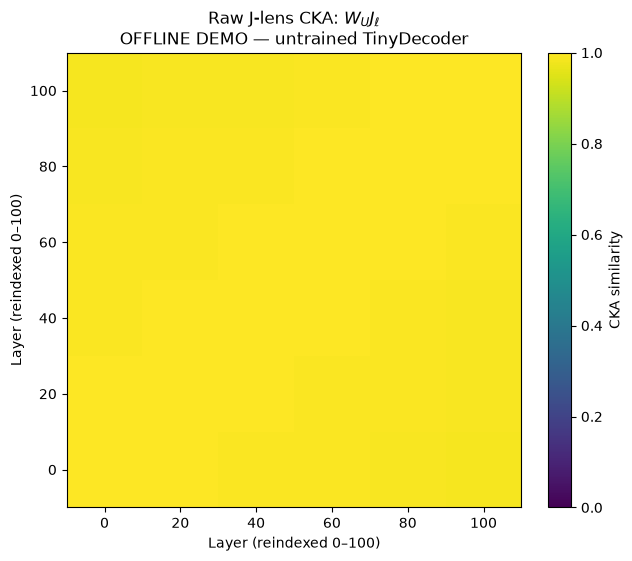

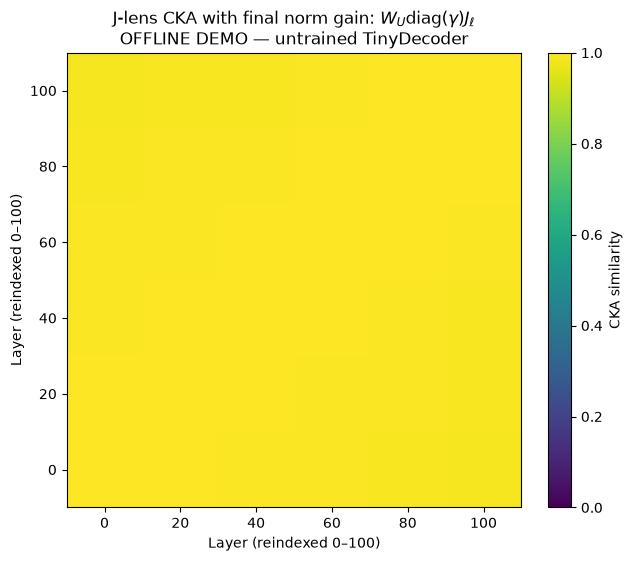

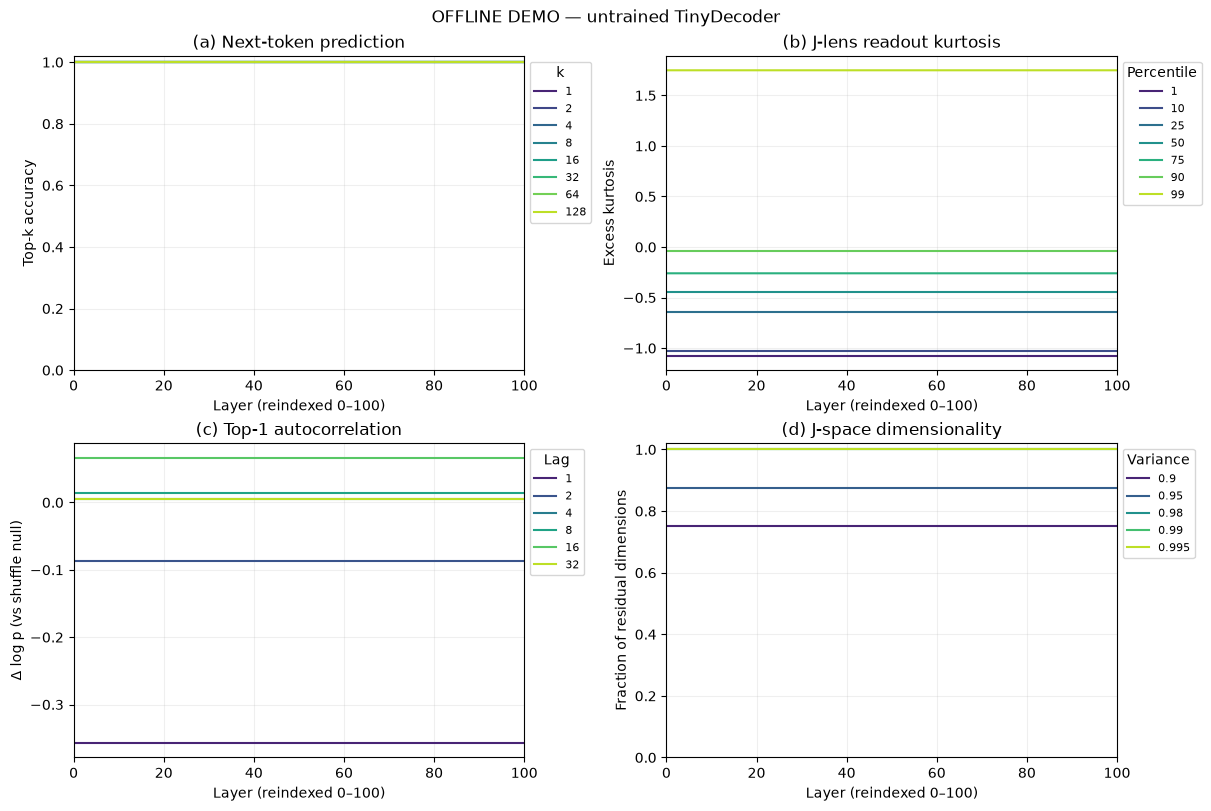

In [13]:
fig27, fig28 = plot_workspace_layers(
    geometry, readouts, n_layers=model.n_layers, title=label,
)
fig27_gain = plot_cka(
    gain_geometry, n_layers=model.n_layers, title=label,
    projection=r"J-lens CKA with final norm gain: $W_U \mathrm{diag}(\gamma) J_\ell$",
)

exports = []
for name, figure in (
    ("figure27_cka", fig27),
    ("figure27_cka_final_norm_gain", fig27_gain),
    ("figure28_layer_diagnostics", fig28),
):
    paths = save_workspace_figure(figure, GEOMETRY_DIR / name)
    exports.append({"figure": name, **{kind: str(path) if path else "skipped (see warning)"
                                      for kind, path in paths.items()}})
display(pd.DataFrame(exports))
for figure in (fig27, fig27_gain, fig28):
    display(figure)
    plt.close(figure)


In [14]:
summary = (
    readouts["accuracy"].query("k == 1")[["layer", "accuracy", "n_tokens"]]
    .rename(columns={"accuracy": "top1_agreement"})
    .merge(readouts["kurtosis"].query("percentile == 50")
           [["layer", "excess_kurtosis", "n_valid"]], on="layer")
    .merge(readouts["autocorrelation"].query("lag == 1")
           [["layer", "delta_log_p", "n_pairs"]], on="layer")
    .merge(geometry.dimensions.query("variance == 0.99")
           [["layer", "dimension_fraction"]], on="layer")
)
display(summary.round(4))
print("Readout tables:", RESULT_DIR)
print("Figures and geometry tables:", GEOMETRY_DIR)
print("Demo results only." if RUN_MODE == "demo" else "Measured model: " + runtime["model_id"])

,layer,top1_agreement,n_tokens,excess_kurtosis,n_valid,delta_log_p,n_pairs,dimension_fraction
0,0,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
1,1,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
2,2,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
3,3,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
4,4,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
5,5,1.0,9334,-0.4467,9334,-0.3574,9191,1.0


Readout tables: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/measurements/eeccf13f05efaed3
Figures and geometry tables: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/geometry/248452f651d7f7f9
Demo results only.


## Conclusions

The executed demo shows that the notebook produces both CKA heatmaps and the four-panel diagnostic, with final-layer prediction agreement equal to one and unit self-similarity for nondegenerate CKA. The tiny decoder is untrained and nearly linear: its patterns should not be interpreted as evidence for sensory, workspace, or motor regions.

For a trained-model run, first compare the raw and gain-weighted heatmaps: any change is due to the final normalization scale, with the same prefitted Jacobians and vocabulary. Then examine whether broad CKA blocks coincide with changes in all four diagnostics. Agreement with a model's output does not measure task correctness, and a CKA block alone does not identify a functional workspace. Report the model/revision, lens provenance, actual fitting corpus, dtype, sequence limit, dimension batch size, evaluation corpus, and seed from the saved manifests. Interpret missing autocorrelation points using the pair-count table. Repeat with more fitting data and held-out natural text before making claims about layer boundaries.